
# Kimberly NLP Analysis Notebook (Revised)

This notebook is the **full revised version** for the micro-creator project.

It includes:
- data loading and group definition
- text cleaning
- **distinctive word analysis** instead of raw frequency-only word clouds
- custom stopword removal for generic platform words such as `video`, `vlog`, and `study`
- VADER sentiment analysis
- **strongly positive ratio** analysis (`compound > 0.8`)
- positive-comment bigram analysis
- LDA topic modeling
- export of figures and CSV outputs for report and slides

**Put this notebook in the same folder as the CSV files before running.**


In [1]:

import os
import re
import ast
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

OUTPUT_DIR = "nlp_outputs_revised"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output folder ready:", OUTPUT_DIR)


Output folder ready: nlp_outputs_revised



## 1. Load the data

The notebook tries multiple common filenames automatically.


In [2]:

candidate_detail_files = [
    "micro_creator_success_patterns_detail.csv",
    "micro_creator_success_patterns_detail(1).csv"
]

candidate_insight_files = [
    "micro_creator_insights.csv",
    "micro_creator_insights(1).csv"
]

detail_path = next((f for f in candidate_detail_files if os.path.exists(f)), None)
insight_path = next((f for f in candidate_insight_files if os.path.exists(f)), None)

if detail_path is None:
    raise FileNotFoundError("Could not find micro_creator_success_patterns_detail.csv")

detail_df = pd.read_csv(detail_path)
insight_df = pd.read_csv(insight_path) if insight_path is not None else pd.DataFrame()

print("Detail file:", detail_path, detail_df.shape)
if not insight_df.empty:
    print("Insights file:", insight_path, insight_df.shape)

detail_df.head(3)


Detail file: micro_creator_success_patterns_detail.csv (1090, 43)
Insights file: micro_creator_insights.csv (16, 4)


,video_id,video_title,description,tags,category_id,published_at,channel_id,channel_title,view_count,like_count,...,has_question_mark,has_exclamation,title_hashtag_count,desc_hashtag_count,is_vlog,is_short,is_daily_life,is_first_video,duration_seconds,duration_bucket
0,ZbxxbwKU89c,mt15 ... #viralvideo #terending #mydreambike #...,mt15 ... #viralvideo #terending #mydreambike #...,NaN,22,2026-04-14 11:53:19+00:00,UCk9FIlO0LEuNloLxTERQH4Q,Akash Kumar@,624,8,...,0,0,6,8,1,0,0,1,18.0,<=1 min
1,2ThqSZnSXn4,My First Vlog #youtubeshorts #shorts #villagel...,My First Vlog #youtubeshorts #shorts #villagel...,dasharathprajapativlog96 ||| dasharathprajapat...,22,2026-04-14 11:35:00+00:00,UCQO3oW5YH7jx9KyemPt68Wg,Dasharath Prajapati Vlogs 96,412,5,...,0,0,4,4,1,1,0,1,57.0,<=1 min
2,xJn7zCZeSxU,My first vlog please support #viral vlog 1.2 M...,आज के इस व्लॉग में मैं [जगह का नाम/गतिविधि] की...,NaN,22,2026-04-14 11:12:18+00:00,UC1wqW1cOllIoqgAVMFpJhSA,Ajit Official,58,7,...,0,1,1,2,1,0,0,1,10.0,<=1 min



## 2. Quick schema check


In [3]:

print(detail_df.columns.tolist())

required_cols = ["video_title", "description", "top_comments_text", "like_rate"]
missing = [c for c in required_cols if c not in detail_df.columns]
print("Missing required columns:", missing)


['video_id', 'video_title', 'description', 'tags', 'category_id', 'published_at', 'channel_id', 'channel_title', 'view_count', 'like_count', 'comment_count', 'duration', 'subscriber_count', 'hashtags_from_title', 'hashtags_from_desc', 'hashtag_count', 'top_comments_text', 'comment_like_count', 'like_rate', 'log_view_count', 'log_like_count', 'log_comment_count', 'log_subscriber_count', 'scaled_log_view_count', 'scaled_log_like_count', 'scaled_log_comment_count', 'scaled_log_subscriber_count', 'scaled_like_rate', 'scaled_hashtag_count', 'like_rate_group', 'post_hour', 'post_day', 'desc_length', 'has_question_mark', 'has_exclamation', 'title_hashtag_count', 'desc_hashtag_count', 'is_vlog', 'is_short', 'is_daily_life', 'is_first_video', 'duration_seconds', 'duration_bucket']
Missing required columns: []



## 3. Build high and low like-rate groups

Preferred logic:
- If `like_rate_group` exists, use it directly
- Otherwise create quartiles from `like_rate`


In [4]:

df = detail_df.copy()

if "like_rate_group" in df.columns:
    # normalize labels
    group_series = df["like_rate_group"].astype(str).str.lower().str.strip()
    high_mask = group_series.str.contains("high")
    low_mask = group_series.str.contains("low")
    if high_mask.sum() == 0 or low_mask.sum() == 0:
        # fallback: infer from numeric if possible
        try:
            temp = pd.to_numeric(df["like_rate_group"], errors="coerce")
            q1 = temp.quantile(0.25)
            q3 = temp.quantile(0.75)
            df["analysis_group"] = np.where(temp >= q3, "High", np.where(temp <= q1, "Low", "Middle"))
        except:
            q1 = df["like_rate"].quantile(0.25)
            q3 = df["like_rate"].quantile(0.75)
            df["analysis_group"] = np.where(df["like_rate"] >= q3, "High", np.where(df["like_rate"] <= q1, "Low", "Middle"))
    else:
        df["analysis_group"] = np.where(high_mask, "High", np.where(low_mask, "Low", "Middle"))
else:
    q1 = df["like_rate"].quantile(0.25)
    q3 = df["like_rate"].quantile(0.75)
    df["analysis_group"] = np.where(df["like_rate"] >= q3, "High", np.where(df["like_rate"] <= q1, "Low", "Middle"))

analysis_df = df[df["analysis_group"].isin(["High", "Low"])].copy()

print(analysis_df["analysis_group"].value_counts())
analysis_df[["video_title", "like_rate", "analysis_group"]].head()


analysis_group
Low     545
High    545
Name: count, dtype: int64


,video_title,like_rate,analysis_group
0,mt15 ... #viralvideo #terending #mydreambike #...,0.012821,Low
1,My First Vlog #youtubeshorts #shorts #villagel...,0.012136,Low
2,My first vlog please support #viral vlog 1.2 M...,0.120690,High
3,My First Vlog | Aaj Se New Journey Start! #vlo...,0.000000,Low
4,ALHAMDULILLAH MY FIRST VLOG #YOUTUBE #VIRALVID...,0.125000,High



## 4. Create combined text fields

We use:
- title
- description
- top comments

We keep both:
- `content_text` = title + description
- `full_text` = title + description + comments


In [5]:

for col in ["video_title", "description", "top_comments_text"]:
    if col not in analysis_df.columns:
        analysis_df[col] = ""
    analysis_df[col] = analysis_df[col].fillna("").astype(str)

analysis_df["content_text"] = (
    analysis_df["video_title"].fillna("") + " " + analysis_df["description"].fillna("")
).str.strip()

analysis_df["full_text"] = (
    analysis_df["video_title"].fillna("") + " " +
    analysis_df["description"].fillna("") + " " +
    analysis_df["top_comments_text"].fillna("")
).str.strip()

analysis_df[["content_text", "full_text"]].head(2)


,content_text,full_text
0,mt15 ... #viralvideo #terending #mydreambike #...,mt15 ... #viralvideo #terending #mydreambike #...
1,My First Vlog #youtubeshorts #shorts #villagel...,My First Vlog #youtubeshorts #shorts #villagel...



## 5. Text cleaning

We remove:
- URLs
- punctuation
- extra spaces
- generic platform words for the **distinctive language** analysis


In [6]:

BASE_STOPWORDS = {
    "the","and","is","to","of","in","for","on","with","this","that","it","my","your",
    "a","an","at","be","are","was","were","am","as","by","from","or","if","but","so",
    "me","we","you","they","he","she","them","our","us","their","his","her","i","im",
    "its","into","out","up","down","about","just","can","will","would","could","should",
    "have","has","had","do","does","did","not","no","yes","all","any","some","more",
    "very","really","get","got","go","goes","going","come","came","make","made","take",
    "today","day","days","one","two","first","new","latest","best","good","nice"
}

GENERIC_PLATFORM_STOPWORDS = {
    "video","videos","vlog","vlogs","study","studying","youtube","youtuber","yt","ytshorts",
    "short","shorts","shortvideo","shortvideos","viral","viralshort","viralvideo","subscribe",
    "subscriber","channel","content","creator","creators","upload","uploads","posted","posting",
    "mini","minivlog","daily","dailyvlog","dailylife","reel","reels","fyp","trend","trending",
    "comment","comments","like","likes","share","sharing","watch","watching","intro"
}

LIGHT_KEEP_WORDS = {"life","story","journey","family","love","real","ideas","beginner","routine"}

CUSTOM_STOPWORDS = (BASE_STOPWORDS | GENERIC_PLATFORM_STOPWORDS) - LIGHT_KEEP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_filtered(text, stopwords=CUSTOM_STOPWORDS, min_len=3):
    text = clean_text(text)
    tokens = [w for w in text.split() if len(w) >= min_len and w not in stopwords]
    return tokens

analysis_df["clean_content_text"] = analysis_df["content_text"].apply(clean_text)
analysis_df["clean_full_text"] = analysis_df["full_text"].apply(clean_text)
analysis_df["tokens_content"] = analysis_df["content_text"].apply(tokenize_filtered)
analysis_df["tokens_full"] = analysis_df["full_text"].apply(tokenize_filtered)

analysis_df[["analysis_group","video_title","tokens_content"]].head(3)


,analysis_group,video_title,tokens_content
0,Low,mt15 ... #viralvideo #terending #mydreambike #...,"[terending, mydreambike, bikelovermy, viralsho..."
1,Low,My First Vlog #youtubeshorts #shorts #villagel...,"[youtubeshorts, villagelife, dasharath, youtub..."
2,High,My first vlog please support #viral vlog 1.2 M...,"[please, support, week, ago, travelvlog, keywo..."



## 6. Text coverage summary


In [7]:

coverage = pd.DataFrame({
    "metric": ["rows_total", "rows_high", "rows_low", "avg_content_text_len", "avg_full_text_len"],
    "value": [
        len(analysis_df),
        (analysis_df["analysis_group"]=="High").sum(),
        (analysis_df["analysis_group"]=="Low").sum(),
        analysis_df["content_text"].str.len().mean(),
        analysis_df["full_text"].str.len().mean(),
    ]
})
coverage.to_csv(os.path.join(OUTPUT_DIR, "text_coverage_summary.csv"), index=False)
coverage


,metric,value
0,rows_total,1090.000000
1,rows_high,545.000000
2,rows_low,545.000000
3,avg_content_text_len,433.094495
4,avg_full_text_len,495.260550



## 7. Sentiment analysis (VADER)

We score the `full_text` field.


In [8]:

# VADER setup with automatic lexicon download if needed
from nltk import download as nltk_download
try:
    from nltk.sentiment import SentimentIntensityAnalyzer
    try:
        sia = SentimentIntensityAnalyzer()
    except:
        nltk_download("vader_lexicon")
        sia = SentimentIntensityAnalyzer()
except Exception as e:
    raise ImportError("NLTK VADER is required. Please install nltk if missing.") from e

analysis_df["vader_compound"] = analysis_df["full_text"].fillna("").apply(lambda x: sia.polarity_scores(str(x))["compound"])
analysis_df["strongly_positive"] = (analysis_df["vader_compound"] > 0.8).astype(int)

sent_summary = analysis_df.groupby("analysis_group").agg(
    avg_compound=("vader_compound", "mean"),
    median_compound=("vader_compound", "median"),
    strongly_positive_ratio=("strongly_positive", "mean"),
    n=("vader_compound", "size")
).reset_index()

sent_summary["strongly_positive_pct"] = sent_summary["strongly_positive_ratio"] * 100
sent_summary.to_csv(os.path.join(OUTPUT_DIR, "sentiment_summary_by_group.csv"), index=False)
sent_summary


,analysis_group,avg_compound,median_compound,strongly_positive_ratio,n,strongly_positive_pct
0,High,0.419069,0.4588,0.330275,545,33.027523
1,Low,0.327392,0.0000,0.229358,545,22.935780


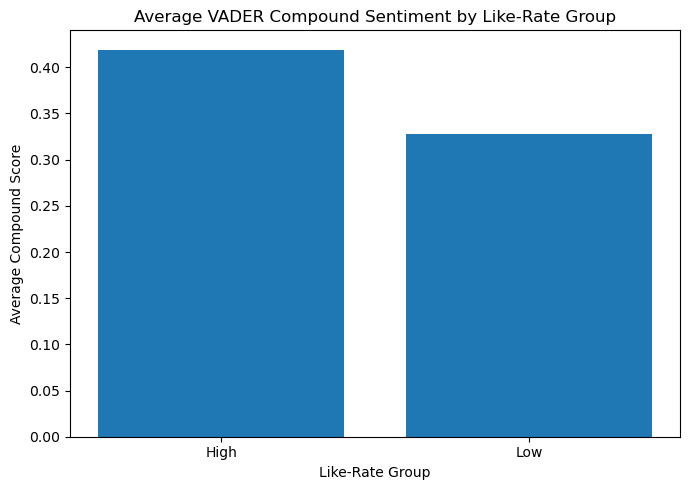

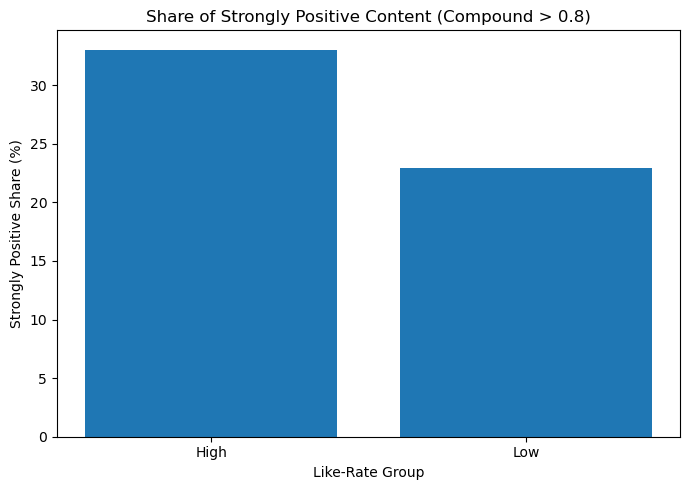

In [9]:

# Average compound bar
plot_df = sent_summary.copy()
plt.figure(figsize=(7,5))
plt.bar(plot_df["analysis_group"], plot_df["avg_compound"])
plt.title("Average VADER Compound Sentiment by Like-Rate Group")
plt.xlabel("Like-Rate Group")
plt.ylabel("Average Compound Score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_compound_bar.png"), dpi=300)
plt.show()

# Strongly positive ratio bar
plt.figure(figsize=(7,5))
plt.bar(plot_df["analysis_group"], plot_df["strongly_positive_pct"])
plt.title("Share of Strongly Positive Content (Compound > 0.8)")
plt.xlabel("Like-Rate Group")
plt.ylabel("Strongly Positive Share (%)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "strongly_positive_ratio_bar.png"), dpi=300)
plt.show()



## 8. Distinctive word analysis

Instead of raw word clouds dominated by `vlog` and `video`, we compare **distinctive language** between groups.

This is what should go on the slide.


In [10]:

def build_group_token_counts(df_in, group_name, token_col):
    subset = df_in[df_in["analysis_group"] == group_name]
    all_tokens = [token for row in subset[token_col] for token in row]
    counter = Counter(all_tokens)
    return counter, len(subset)

high_counter, n_high = build_group_token_counts(analysis_df, "High", "tokens_content")
low_counter, n_low = build_group_token_counts(analysis_df, "Low", "tokens_content")

all_words = sorted(set(high_counter) | set(low_counter))

rows = []
for word in all_words:
    high_rate = high_counter[word] / n_high if n_high else 0
    low_rate = low_counter[word] / n_low if n_low else 0
    rows.append({
        "word": word,
        "high_rate": high_rate,
        "low_rate": low_rate,
        "difference_high_minus_low": high_rate - low_rate,
        "abs_difference": abs(high_rate - low_rate)
    })

word_diff_df = pd.DataFrame(rows).sort_values("abs_difference", ascending=False)
top_high_words = word_diff_df.sort_values("difference_high_minus_low", ascending=False).head(25)
top_low_words = word_diff_df.sort_values("difference_high_minus_low", ascending=True).head(25).copy()
top_low_words["difference_high_minus_low"] = top_low_words["difference_high_minus_low"].abs()

top_high_words.to_csv(os.path.join(OUTPUT_DIR, "top_words_more_common_in_high.csv"), index=False)
top_low_words.to_csv(os.path.join(OUTPUT_DIR, "top_words_more_common_in_low.csv"), index=False)

top_high_words.head(), top_low_words.head()


(          word  high_rate  low_rate  difference_high_minus_low  abs_difference
 3856       jee   0.748624  0.091743                   0.656881        0.656881
 3207  haridwar   0.190826  0.000000                   0.190826        0.190826
 3514     ideas   0.214679  0.029358                   0.185321        0.185321
 6811   shayari   0.165138  0.000000                   0.165138        0.165138
 3527       iit   0.176147  0.011009                   0.165138        0.165138,
        word  high_rate  low_rate  difference_high_minus_low  abs_difference
 2733   food   0.135780  0.299083                   0.163303        0.163303
 7165    ssc   0.007339  0.168807                   0.161468        0.161468
 3586  india   0.113761  0.275229                   0.161468        0.161468
 1377  class   0.170642  0.306422                   0.135780        0.135780
 8069   upsc   0.003670  0.135780                   0.132110        0.132110)

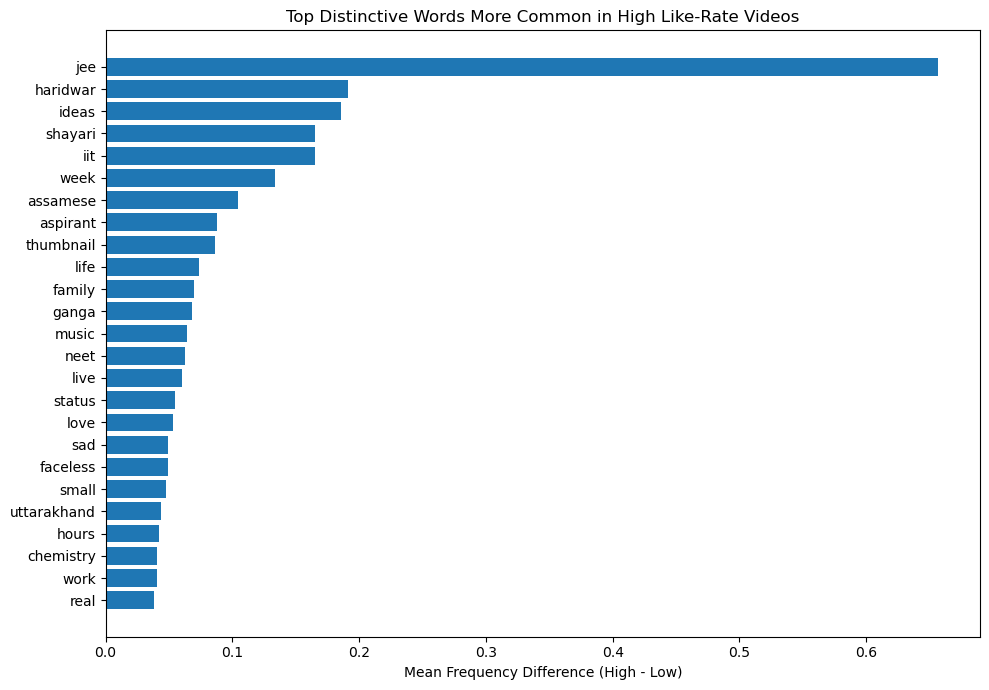

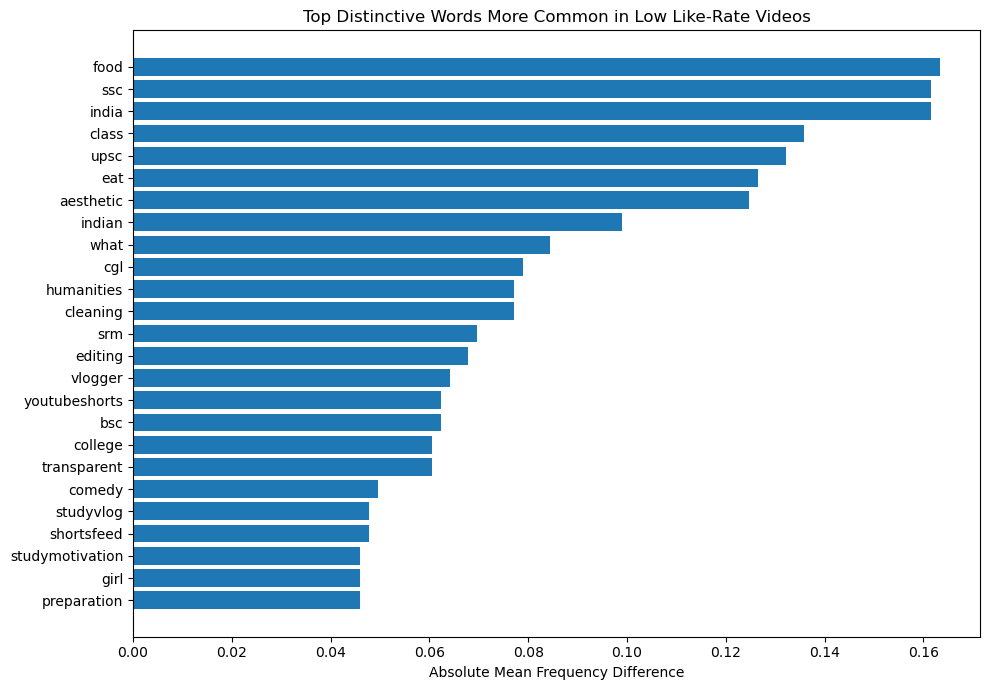

In [11]:

# Plot top high words
plot_high = top_high_words.sort_values("difference_high_minus_low", ascending=True)
plt.figure(figsize=(10,7))
plt.barh(plot_high["word"], plot_high["difference_high_minus_low"])
plt.title("Top Distinctive Words More Common in High Like-Rate Videos")
plt.xlabel("Mean Frequency Difference (High - Low)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_high_words_bar.png"), dpi=300)
plt.show()

# Plot top low words
plot_low = top_low_words.sort_values("difference_high_minus_low", ascending=True)
plt.figure(figsize=(10,7))
plt.barh(plot_low["word"], plot_low["difference_high_minus_low"])
plt.title("Top Distinctive Words More Common in Low Like-Rate Videos")
plt.xlabel("Absolute Mean Frequency Difference")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_low_words_bar.png"), dpi=300)
plt.show()



## 9. Distinctive word cloud (optional)

These word clouds use **difference-based words**, not raw frequency words.
If `wordcloud` is unavailable, the notebook simply skips this section.


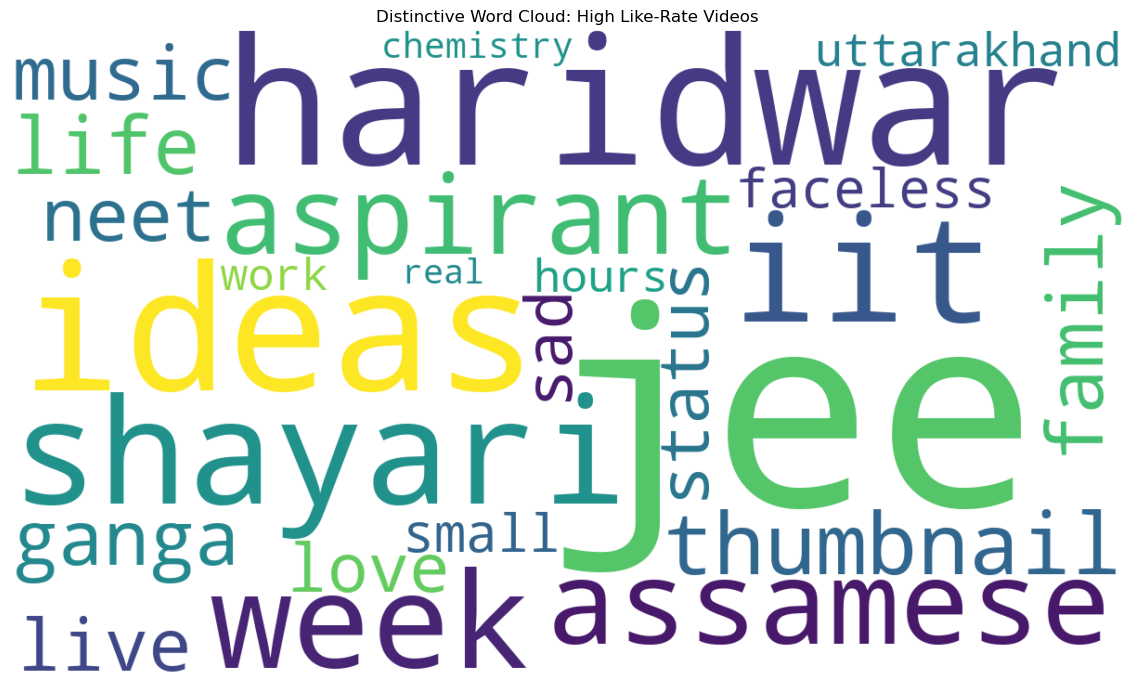

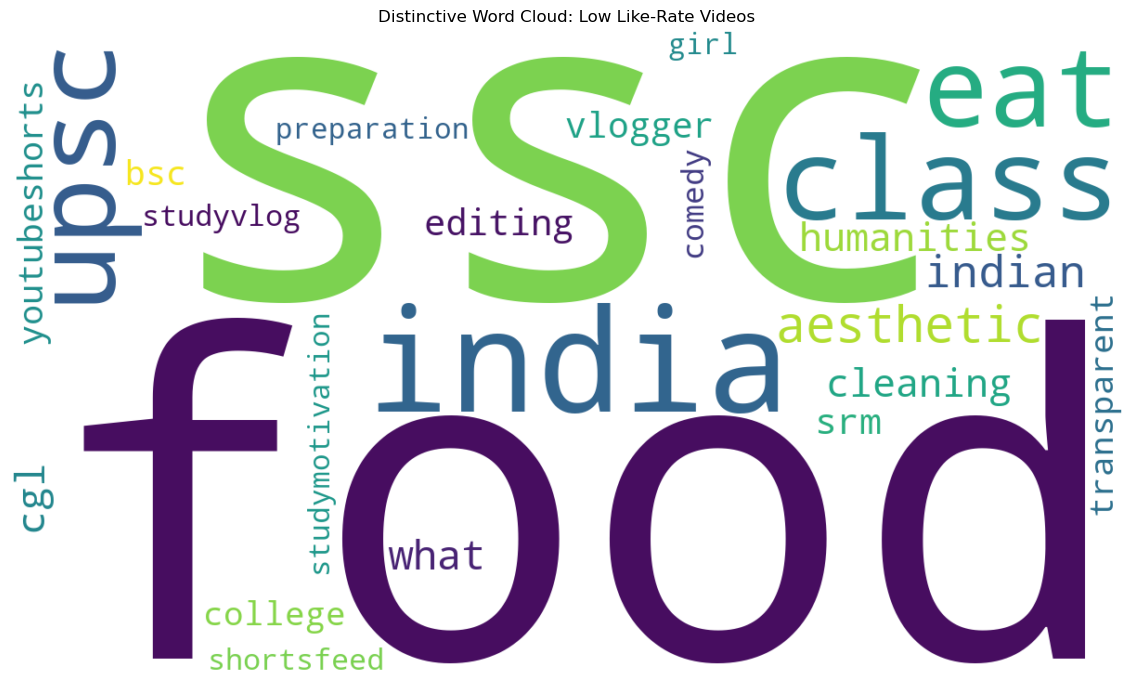

In [12]:

try:
    from wordcloud import WordCloud
    wordcloud_available = True
except:
    wordcloud_available = False

if wordcloud_available:
    high_freqs = dict(zip(top_high_words["word"], top_high_words["difference_high_minus_low"]))
    low_freqs = dict(zip(top_low_words["word"], top_low_words["difference_high_minus_low"]))

    wc_high = WordCloud(width=1200, height=700, background_color="white").generate_from_frequencies(high_freqs)
    plt.figure(figsize=(12,7))
    plt.imshow(wc_high, interpolation="bilinear")
    plt.axis("off")
    plt.title("Distinctive Word Cloud: High Like-Rate Videos")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "distinctive_wordcloud_high.png"), dpi=300)
    plt.show()

    wc_low = WordCloud(width=1200, height=700, background_color="white").generate_from_frequencies(low_freqs)
    plt.figure(figsize=(12,7))
    plt.imshow(wc_low, interpolation="bilinear")
    plt.axis("off")
    plt.title("Distinctive Word Cloud: Low Like-Rate Videos")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "distinctive_wordcloud_low.png"), dpi=300)
    plt.show()
else:
    print("wordcloud package not available. Skipping distinctive word cloud section.")



## 10. Positive-text bigrams

We focus on **strongly positive rows** (`compound > 0.8`) and extract bigrams separately for High and Low groups.
This is more actionable than just reporting an average score.


In [13]:

def get_bigrams_from_tokens(tokens_list):
    pairs = []
    for toks in tokens_list:
        toks = [t for t in toks if t not in CUSTOM_STOPWORDS]
        pairs.extend([" ".join((toks[i], toks[i+1])) for i in range(len(toks)-1)])
    return Counter(pairs)

strong_pos_df = analysis_df[analysis_df["strongly_positive"] == 1].copy()

high_pos = strong_pos_df[strong_pos_df["analysis_group"]=="High"].copy()
low_pos = strong_pos_df[strong_pos_df["analysis_group"]=="Low"].copy()

high_pos_bigrams = get_bigrams_from_tokens(high_pos["tokens_full"])
low_pos_bigrams = get_bigrams_from_tokens(low_pos["tokens_full"])

high_pos_df = pd.DataFrame(high_pos_bigrams.items(), columns=["bigram", "count"]).sort_values("count", ascending=False)
low_pos_df = pd.DataFrame(low_pos_bigrams.items(), columns=["bigram", "count"]).sort_values("count", ascending=False)

high_pos_df.to_csv(os.path.join(OUTPUT_DIR, "positive_bigrams_high.csv"), index=False)
low_pos_df.to_csv(os.path.join(OUTPUT_DIR, "positive_bigrams_low.csv"), index=False)

high_pos_df.head(20), low_pos_df.head(20)


(                  bigram  count
 2182        jee aspirant     41
 8229           week life     37
 821            real life     27
 2251         routine jee     26
 2181             iit jee     25
 2193             jee jee     24
 2213            life jee     23
 6958        love shayari     23
 12434  haridwar haridwar     21
 79            don forget     21
 1808        student life     21
 2229            life iit     20
 1828       aspirant life     20
 6921         sad shayari     19
 12401        ganga aarti     19
 2305     jee preparation     17
 2302           life life     17
 2287            jee exam     15
 6441         ideas ideas     15
 6935     shayari shayari     15,
                     bigram  count
 1174               ssc cgl     38
 3112              what eat     37
 1772           class class     36
 372                how how     28
 1405       morning routine     25
 375             kaise kare     25
 959           student life     22
 1175       cgl preparatio

In [14]:

# Distinctive positive bigrams
def normalize_counter(counter, n_rows):
    return {k: v / max(n_rows, 1) for k, v in counter.items()}

high_bi_norm = normalize_counter(high_pos_bigrams, max(len(high_pos),1))
low_bi_norm = normalize_counter(low_pos_bigrams, max(len(low_pos),1))

all_bigrams = sorted(set(high_bi_norm) | set(low_bi_norm))
bi_rows = []
for bg in all_bigrams:
    h = high_bi_norm.get(bg, 0)
    l = low_bi_norm.get(bg, 0)
    bi_rows.append({
        "bigram": bg,
        "high_rate": h,
        "low_rate": l,
        "difference_high_minus_low": h - l,
        "abs_difference": abs(h - l)
    })

bi_diff_df = pd.DataFrame(bi_rows)
top_high_bigrams = bi_diff_df.sort_values("difference_high_minus_low", ascending=False).head(20)
top_low_bigrams = bi_diff_df.sort_values("difference_high_minus_low", ascending=True).head(20).copy()
top_low_bigrams["difference_high_minus_low"] = top_low_bigrams["difference_high_minus_low"].abs()

top_high_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams_more_common_in_high.csv"), index=False)
top_low_bigrams.to_csv(os.path.join(OUTPUT_DIR, "top_bigrams_more_common_in_low.csv"), index=False)

top_high_bigrams.head(10), top_low_bigrams.head(10)


(                  bigram  high_rate  low_rate  difference_high_minus_low  \
 9368        jee aspirant   0.227778     0.032                   0.195778   
 15216        routine jee   0.144444     0.000                   0.144444   
 11203       love shayari   0.127778     0.000                   0.127778   
 9399             jee jee   0.133333     0.008                   0.125333   
 7811   haridwar haridwar   0.116667     0.000                   0.116667   
 10637           life jee   0.127778     0.016                   0.111778   
 10628           life iit   0.111111     0.000                   0.111111   
 20126          week life   0.205556     0.096                   0.109556   
 8731             iit jee   0.138889     0.032                   0.106889   
 15381        sad shayari   0.105556     0.000                   0.105556   
 
        abs_difference  
 9368         0.195778  
 15216        0.144444  
 11203        0.127778  
 9399         0.125333  
 7811         0.116667  
 

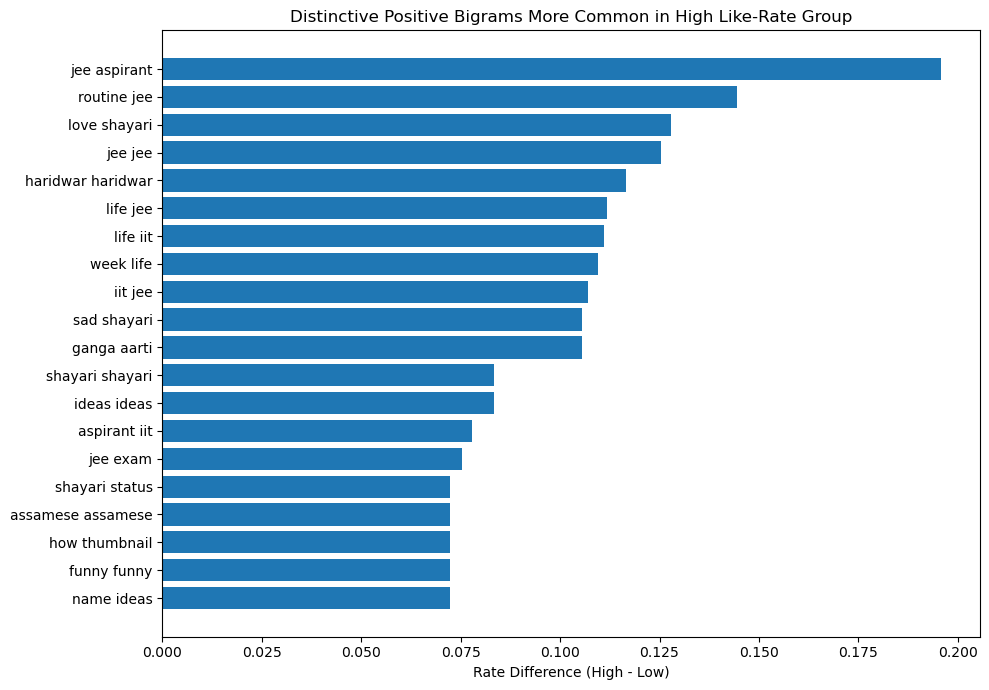

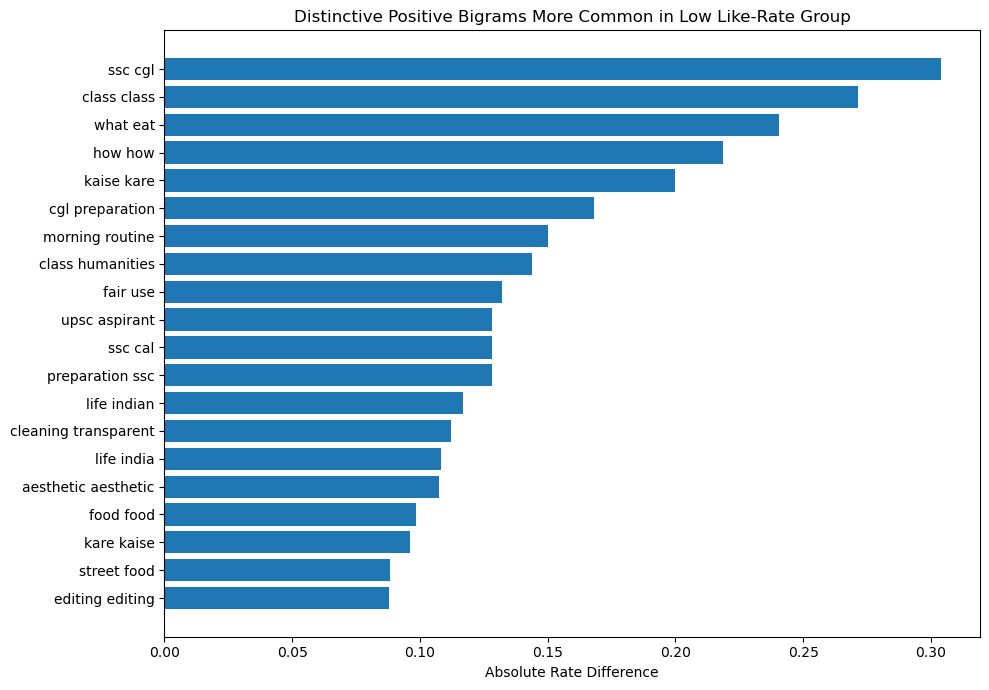

In [15]:

plt.figure(figsize=(10,7))
plot_bi_high = top_high_bigrams.sort_values("difference_high_minus_low", ascending=True)
plt.barh(plot_bi_high["bigram"], plot_bi_high["difference_high_minus_low"])
plt.title("Distinctive Positive Bigrams More Common in High Like-Rate Group")
plt.xlabel("Rate Difference (High - Low)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_high_positive_bigrams_bar.png"), dpi=300)
plt.show()

plt.figure(figsize=(10,7))
plot_bi_low = top_low_bigrams.sort_values("difference_high_minus_low", ascending=True)
plt.barh(plot_bi_low["bigram"], plot_bi_low["difference_high_minus_low"])
plt.title("Distinctive Positive Bigrams More Common in Low Like-Rate Group")
plt.xlabel("Absolute Rate Difference")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_low_positive_bigrams_bar.png"), dpi=300)
plt.show()



## 11. Topic modeling (LDA)

We use cleaned **content text** (title + description) for topic modeling, because this reflects creator-side content positioning better than comments.


In [16]:

def fit_lda_for_group(df_in, group_name, text_col="clean_content_text", n_topics=5, max_features=1000):
    subset = df_in[df_in["analysis_group"] == group_name].copy()
    texts = subset[text_col].fillna("").tolist()

    vectorizer = CountVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        max_features=max_features,
        min_df=2
    )
    X = vectorizer.fit_transform(texts)

    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method="batch"
    )
    topic_matrix = lda.fit_transform(X)
    vocab = vectorizer.get_feature_names_out()

    topic_rows = []
    for topic_idx, topic_weights in enumerate(lda.components_):
        top_idx = topic_weights.argsort()[::-1][:10]
        top_words = [vocab[i] for i in top_idx]
        topic_rows.append({
            "topic": f"topic_{topic_idx+1}",
            "top_1_10_words": ", ".join(top_words),
            "top_1": top_words[0],
            "top_2": top_words[1] if len(top_words) > 1 else "",
            "top_3": top_words[2] if len(top_words) > 2 else "",
            "top_4": top_words[3] if len(top_words) > 3 else "",
            "top_5": top_words[4] if len(top_words) > 4 else ""
        })

    topic_df = pd.DataFrame(topic_rows)
    dominant_topic = topic_matrix.argmax(axis=1)
    dist = pd.Series(dominant_topic).value_counts(normalize=True).sort_index()
    dist_df = pd.DataFrame({
        "topic": [f"topic_{i+1}" for i in range(n_topics)],
        "share_of_videos": [dist.get(i, 0) for i in range(n_topics)]
    })

    return subset, vectorizer, lda, topic_df, dist_df

high_subset, high_vec, high_lda, high_topics_df, high_dist_df = fit_lda_for_group(analysis_df, "High")
low_subset, low_vec, low_lda, low_topics_df, low_dist_df = fit_lda_for_group(analysis_df, "Low")

high_topics_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics_high.csv"), index=False)
low_topics_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics_low.csv"), index=False)
high_dist_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topic_distribution_high.csv"), index=False)
low_dist_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topic_distribution_low.csv"), index=False)

display(high_topics_df)
display(low_topics_df)


,topic,top_1_10_words,top_1,top_2,top_3,top_4,top_5
0,topic_1,"ideas, ki, hai, ka, aur, love, youtubeshorts, ...",ideas,ki,hai,ka,aur
1,topic_2,"life, week, food, live, what, work, focus, sta...",life,week,food,live,what
2,topic_3,"small, college, support, life, how, journey, r...",small,college,support,life,how
3,topic_4,"life, funny, week, thumbnail, assamese, aesthe...",life,funny,week,thumbnail,assamese
4,topic_5,"jee, life, routine, iit, aspirant, class, stud...",jee,life,routine,iit,aspirant


,topic,top_1_10_words,top_1,top_2,top_3,top_4,top_5
0,topic_1,"life, routine, india, college, aesthetic, vlog...",life,routine,india,college,aesthetic
1,topic_2,"class, how, th, upsc, kaise, motivation, study...",class,how,th,upsc,kaise
2,topic_3,"ssc, support, small, gaming, preparation, jour...",ssc,support,small,gaming,preparation
3,topic_4,"food, what, eat, jee, life, whatieatinaday, st...",food,what,eat,jee,life
4,topic_5,"comedy, aesthetic, ke, cleaning, aur, college,...",comedy,aesthetic,ke,cleaning,aur


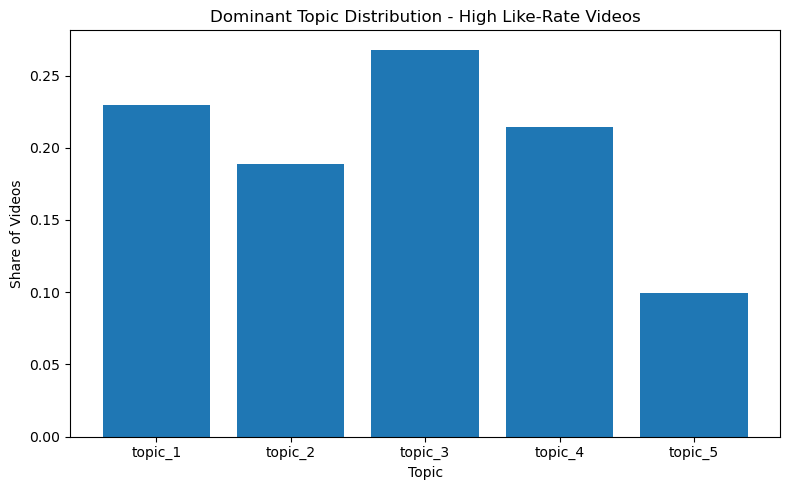

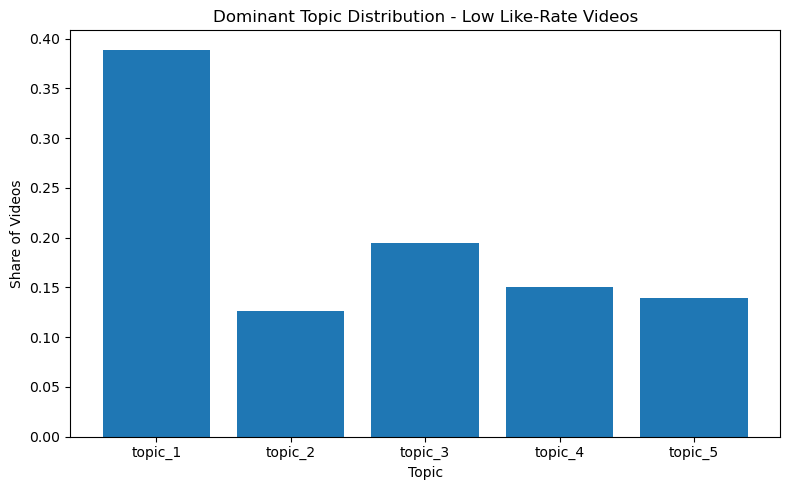

In [17]:

plt.figure(figsize=(8,5))
plt.bar(high_dist_df["topic"], high_dist_df["share_of_videos"])
plt.title("Dominant Topic Distribution - High Like-Rate Videos")
plt.xlabel("Topic")
plt.ylabel("Share of Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lda_distribution_high.png"), dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(low_dist_df["topic"], low_dist_df["share_of_videos"])
plt.title("Dominant Topic Distribution - Low Like-Rate Videos")
plt.xlabel("Topic")
plt.ylabel("Share of Videos")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lda_distribution_low.png"), dpi=300)
plt.show()



## 12. Topic saturation summary

This quantifies whether one group is more concentrated in a single topic.


In [18]:

topic_saturation_summary = pd.DataFrame({
    "group": ["High", "Low"],
    "max_topic_share": [high_dist_df["share_of_videos"].max(), low_dist_df["share_of_videos"].max()],
    "entropy_proxy": [
        -(high_dist_df["share_of_videos"] * np.log(high_dist_df["share_of_videos"] + 1e-12)).sum(),
        -(low_dist_df["share_of_videos"] * np.log(low_dist_df["share_of_videos"] + 1e-12)).sum()
    ]
})
topic_saturation_summary.to_csv(os.path.join(OUTPUT_DIR, "topic_saturation_summary.csv"), index=False)
topic_saturation_summary


,group,max_topic_share,entropy_proxy
0,High,0.267890,1.564818
1,Low,0.388991,1.507096



## 13. Slide-ready evidence tables


In [19]:

# compact evidence table for reporting
evidence_rows = []

# sentiment evidence
high_avg = sent_summary.loc[sent_summary["analysis_group"]=="High", "avg_compound"].iloc[0]
low_avg = sent_summary.loc[sent_summary["analysis_group"]=="Low", "avg_compound"].iloc[0]
high_sp = sent_summary.loc[sent_summary["analysis_group"]=="High", "strongly_positive_pct"].iloc[0]
low_sp = sent_summary.loc[sent_summary["analysis_group"]=="Low", "strongly_positive_pct"].iloc[0]

evidence_rows.append({
    "insight": "Emotional connection",
    "evidence": f"Average compound: High={high_avg:.3f}, Low={low_avg:.3f}; Strongly positive share: High={high_sp:.1f}%, Low={low_sp:.1f}%"
})

# distinctive words evidence
evidence_rows.append({
    "insight": "Distinctive language",
    "evidence": "High group words: " + ", ".join(top_high_words["word"].head(5).tolist()) +
                " | Low group words: " + ", ".join(top_low_words["word"].head(5).tolist())
})

# topic saturation evidence
high_max = high_dist_df["share_of_videos"].max()
low_max = low_dist_df["share_of_videos"].max()
evidence_rows.append({
    "insight": "Topic saturation",
    "evidence": f"Max dominant-topic share: High={high_max:.3f}, Low={low_max:.3f}"
})

evidence_table = pd.DataFrame(evidence_rows)
evidence_table.to_csv(os.path.join(OUTPUT_DIR, "slide_ready_evidence_table.csv"), index=False)
evidence_table


,insight,evidence
0,Emotional connection,"Average compound: High=0.419, Low=0.327; Stron..."
1,Distinctive language,"High group words: jee, haridwar, ideas, shayar..."
2,Topic saturation,"Max dominant-topic share: High=0.268, Low=0.389"



## 14. Final interpretation helper

Run this cell to print a quick draft summary using your actual numbers.


In [20]:

high_avg = sent_summary.loc[sent_summary["analysis_group"]=="High", "avg_compound"].iloc[0]
low_avg = sent_summary.loc[sent_summary["analysis_group"]=="Low", "avg_compound"].iloc[0]
high_sp = sent_summary.loc[sent_summary["analysis_group"]=="High", "strongly_positive_pct"].iloc[0]
low_sp = sent_summary.loc[sent_summary["analysis_group"]=="Low", "strongly_positive_pct"].iloc[0]

high_words_str = ", ".join(top_high_words["word"].head(8).tolist())
low_words_str = ", ".join(top_low_words["word"].head(8).tolist())

summary = f'''
Key findings:

1. Emotional connection:
High like-rate content has a higher average VADER score ({high_avg:.3f} vs {low_avg:.3f}).
More importantly, the share of strongly positive content (compound > 0.8) is {high_sp:.1f}% in High vs {low_sp:.1f}% in Low.

2. Distinctive language:
High group distinctive words: {high_words_str}
Low group distinctive words: {low_words_str}

3. Topic concentration:
High max topic share = {high_max:.3f}
Low max topic share = {low_max:.3f}
If the Low group is more concentrated, that suggests content homogeneity and topic saturation.
'''
print(summary)



Key findings:

1. Emotional connection:
High like-rate content has a higher average VADER score (0.419 vs 0.327).
More importantly, the share of strongly positive content (compound > 0.8) is 33.0% in High vs 22.9% in Low.

2. Distinctive language:
High group distinctive words: jee, haridwar, ideas, shayari, iit, week, assamese, aspirant
Low group distinctive words: food, ssc, india, class, upsc, eat, aesthetic, indian

3. Topic concentration:
High max topic share = 0.268
Low max topic share = 0.389
If the Low group is more concentrated, that suggests content homogeneity and topic saturation.




## 15. Output checklist

After running the notebook, check the folder:

`nlp_outputs_revised`

Key files include:
- `sentiment_compound_bar.png`
- `strongly_positive_ratio_bar.png`
- `top_high_words_bar.png`
- `top_low_words_bar.png`
- `top_high_positive_bigrams_bar.png`
- `top_low_positive_bigrams_bar.png`
- `lda_distribution_high.png`
- `lda_distribution_low.png`
- `lda_topics_high.csv`
- `lda_topics_low.csv`
- `slide_ready_evidence_table.csv`

For slides, the most important upgrades are:
1. **distinctive words** instead of raw word cloud
2. **strongly positive ratio** instead of average only
3. **positive bigrams** to show what viewers are positive about
